# Tier1Final_S2_1 — critical analysis

Source: `result_bank/quantum_hardware_results/Tier1Final_S2_1.json`  
Run: 2026-06-01, `tier1_subset_sqa_hw.py`, ILP baseline + `SQA_SF_HW` (S2) on `Advantage_system4` (Pegasus).  
Stated config: `annealing_time=50us`, `num_reads=500/1000`, `chain_strength = uniform_torque_compensation(prefactor=1.5)` flat.

This notebook evaluates the run against the paper formulation it implements (Paper 2, Sec. III — unbalanced penalisation for the storage-inequality QUBO). The verdict, up front:

1. **Silent data-loss bug in the harness** — metadata advertises 36 cases, only 12 survive in `results` (all at `tc_tightness=0.7`).
2. **Solver quality is poor** — 2/12 embedding failures, 2/10 invalid solutions, only 1/10 matches the ILP optimum.
3. **`best_num_occurrences=1` on 9/10 cases** — the QPU never converges; the reported costs are not statistically supported as ground states.
4. **The `num_reads` schedule is not enforced** — the chip silently truncates reads on small problems and the harness does not flag it.
5. **The locked `chain_strength` prefactor 1.5 was tuned on `n=3` and fails on `n=9`** — cbf above the team's own concern threshold; both `n=9` cases that embedded returned infeasible solutions.
6. **No metric in the dataset favors the QPU over ILP** — ILP solves every case to provable optimum in ≤240 ms.


## 1. Load the result file

In [ ]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
RESULT_PATH = REPO_ROOT / 'result_bank' / 'quantum_hardware_results' / 'Tier1Final_S2_1.json'

with open(RESULT_PATH) as f:
    data = json.load(f)

meta = data['metadata']
results = data['results']

print(f"metadata.total_cases  : {meta['total_cases']}")
print(f"len(results)          : {len(results)}")
print(f"solvers               : {meta['solvers']}")
print(f"annealing_time (us)   : {meta['annealing_time']}")


### Discrepancy #1 — case count

`metadata.total_cases = 36` but `len(results) = 12`. This is not a partial run: every `(n, p)` configuration appears exactly once, and *every* case has `tc_tightness = 0.7`.


In [2]:
tightnesses = sorted({c.get('tc_tightness') for c in results.values()})
print('Unique tc_tightness values in results:', tightnesses)
print('Lex order on tightness directory names: t100 <', 't100' < 't30' < 't70', '< t30 < t70')

Unique tc_tightness values in results: [0.7]
Lex order on tightness directory names: t100 < True < t30 < t70


### Root cause (in `util/experiment_execution/run_experiment.py:436`)

```python
key = tc_path.stem        # e.g. "n-3_p-12_1"
...
output["results"][key] = entry
```

`tc_path` walks `tier1/n3_p12/{t30,t70,t100}/n-3_p-12_1.json`. The tightness folder is **not** in `tc_path.stem`, so all three tightness variants of the same `(n, p)` write to the same dict key. The harness submits all 36 jobs to the QPU and silently overwrites results. Lex order is `t100 < t30 < t70`, so `t70` wins. **Two-thirds of the QPU data charged to this run is gone.** Any tightness-sensitivity claim built on this file is unsupported.

## 2. Build the per-case dataframe

In [3]:
rows = []
for k, c in results.items():
    ilp = c['solvers']['ILP']
    s   = c['solvers']['SQA_SF_HW']
    rows.append({
        'case': k,
        'n': c['n_nodes'],
        'p': c['n_partitions'],
        'tc_tightness': c.get('tc_tightness'),
        'k_safety': c['k_safety'],
        'case_num_reads_sched': c['case_num_reads'],
        'ILP_cost': ilp.get('cost'),
        'ILP_valid': ilp.get('valid'),
        'ILP_wall_ms': ilp.get('wall_time_ms'),
        'SQA_cost': s.get('cost'),
        'SQA_valid': s.get('valid'),
        'SQA_wall_ms': s.get('wall_time_ms'),
        'gap_rel': s.get('optimality_gap_relative'),
        'gap_abs': s.get('optimality_gap_absolute'),
        'k_safety_violations': s.get('k_safety_violations'),
        'capacity_overruns': s.get('capacity_overruns'),
        'bqm_vars': s.get('bqm_variables'),
        'bqm_interactions': s.get('bqm_interactions'),
        'lambda_1': s.get('lambda_1'),
        'lambda_2': s.get('lambda_2'),
        'phys_qubits': s.get('physical_qubits'),
        'max_chain': s.get('max_chain_length'),
        'mean_chain': s.get('mean_chain_length'),
        'cbf': s.get('chain_break_fraction'),
        'best_energy': s.get('best_energy'),
        'best_num_occurrences': s.get('best_num_occurrences'),
        'num_reads_actual': s.get('num_reads'),
        'qpu_access_ms': (s.get('qpu_access_time_us') or 0) / 1000.0,
        'error': s.get('error'),
    })

df = pd.DataFrame(rows).sort_values(['n','p']).reset_index(drop=True)
df

,case,n,p,tc_tightness,k_safety,case_num_reads_sched,ILP_cost,ILP_valid,ILP_wall_ms,SQA_cost,...,lambda_2,phys_qubits,max_chain,mean_chain,cbf,best_energy,best_num_occurrences,num_reads_actual,qpu_access_ms,error
0,n-3_p-4_1,3,4,0.7,2,500,29,True,67.1,29.0,...,0.100000,18.0,2.0,1.50,0.0000,2.920000e+03,6.0,87.0,89.30036,None
1,n-3_p-12_1,3,12,0.7,2,500,168,True,28.6,312.0,...,130.300000,106.0,5.0,2.94,0.0003,3.002140e+04,1.0,500.0,110.58956,None
2,n-3_p-26_1,3,26,0.7,2,1000,176,True,34.7,493.0,...,93.047619,462.0,10.0,5.92,0.0004,9.810095e+04,1.0,1000.0,240.50116,None
3,n-3_p-50_1,3,50,0.7,2,1000,859,True,99.5,1405.0,...,109.857143,1614.0,18.0,10.76,0.0026,4.269926e+05,1.0,1000.0,283.74156,None
4,n-5_p-4_1,5,4,0.7,2,1000,296,True,127.9,317.0,...,243.666667,41.0,3.0,2.05,0.0001,3.973000e+03,1.0,830.0,193.88156,None
5,n-5_p-12_1,5,12,0.7,2,1000,665,True,107.7,874.0,...,289.666667,252.0,6.0,4.20,0.0007,3.795233e+04,1.0,1000.0,245.78116,None
6,n-5_p-26_1,5,26,0.7,2,1000,1352,True,125.7,2819.0,...,309.000000,1353.0,19.0,10.41,0.0073,1.965630e+05,1.0,1000.0,291.02356,None
7,n-5_p-50_1,5,50,0.7,2,1000,2949,True,63.6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,no embedding found
8,n-9_p-4_1,9,4,0.7,2,1000,658,True,94.7,664.0,...,1004.000000,106.0,4.0,2.94,0.0026,7.693000e+03,1.0,995.0,192.95956,None
9,n-9_p-12_1,9,12,0.7,2,1000,1104,True,92.0,1548.0,...,497.750000,909.0,14.0,8.42,0.0503,5.431050e+04,1.0,1000.0,270.52636,None


## 3. Headline aggregates

In [4]:
ran     = df[df['error'].isna()]
errored = df[df['error'].notna()]
valid   = ran[ran['SQA_valid'] == True]
inval   = ran[ran['SQA_valid'] == False]
match   = ran[(ran['gap_rel'].notna()) & (ran['gap_rel'] == 0.0)]
print(f'Total cases in file        : {len(df)}')
print(f'  Embedding failures       : {len(errored)}  ({", ".join(errored.case)})')
print(f'  Produced a sample        : {len(ran)}')
print(f'    Valid                  : {len(valid)}')
print(f'    Invalid                : {len(inval)}  ({", ".join(inval.case)})')
print(f'    Match ILP optimum      : {len(match)}  ({", ".join(match.case)})')
print()
print('Relative-gap distribution across cases that produced output:')
print(ran['gap_rel'].describe().round(3))

Total cases in file        : 12
  Embedding failures       : 2  (n-5_p-50_1, n-9_p-50_1)
  Produced a sample        : 10
    Valid                  : 8
    Invalid                : 2  (n-9_p-12_1, n-9_p-26_1)
    Match ILP optimum      : 1  (n-3_p-4_1)

Relative-gap distribution across cases that produced output:
count    10.000
mean      0.550
std       0.568
min       0.000
25%       0.132
50%       0.364
75%       0.802
max       1.801
Name: gap_rel, dtype: float64


**Read:** 1 of 10 cases matches ILP — the trivial 12-variable `n-3_p-4`. Median gap **36.4%**, max **180%**. Two cases are infeasible (constraint violations). Two cases failed embedding (`p=50` for `n=5` and `n=9`).

## 4. Convergence: `best_num_occurrences` over the sweep

In [5]:
print(ran[['case', 'bqm_vars', 'num_reads_actual', 'best_num_occurrences', 'SQA_valid', 'gap_rel']].to_string(index=False))

      case  bqm_vars  num_reads_actual  best_num_occurrences  SQA_valid  gap_rel
 n-3_p-4_1      12.0              87.0                   6.0       True   0.0000
n-3_p-12_1      36.0             500.0                   1.0       True   0.8571
n-3_p-26_1      78.0            1000.0                   1.0       True   1.8011
n-3_p-50_1     150.0            1000.0                   1.0       True   0.6356
 n-5_p-4_1      20.0             830.0                   1.0       True   0.0709
n-5_p-12_1      60.0            1000.0                   1.0       True   0.3143
n-5_p-26_1     130.0            1000.0                   1.0       True   1.0851
 n-9_p-4_1      36.0             995.0                   1.0       True   0.0091
n-9_p-12_1     108.0            1000.0                   1.0      False   0.4022
n-9_p-26_1     234.0            1000.0                   1.0      False   0.3260


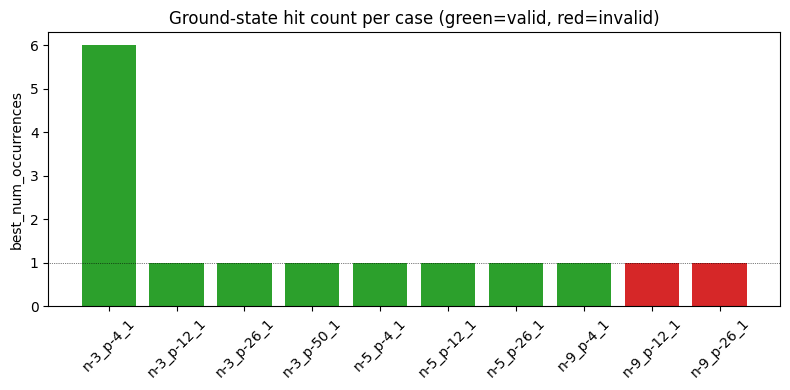

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ran['case'], ran['best_num_occurrences'], color=['#2ca02c' if v else '#d62728' for v in ran['SQA_valid']])
ax.axhline(1, color='k', ls=':', lw=0.5)
ax.set_ylabel('best_num_occurrences')
ax.set_title('Ground-state hit count per case (green=valid, red=invalid)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Read:** `best_num_occurrences = 1` on 9 of 10 cases. The lone exception is the 12-variable trivial case. With 1-out-of-N occurrence there is **no statistical evidence** the reported energy is the true ground state of the BQM. The file's own metadata note acknowledges that the previous tuning runs already had this symptom and that bumping anneal time + reads was meant to fix it — *and the symptom persists in the locked-in config*.

## 5. `num_reads` schedule vs what the chip actually delivered

In [7]:
def scheduled_reads(n, p):
    return 1000 if (n >= 5 or p >= 26) else 500

ran = ran.copy()
ran['num_reads_sched'] = [scheduled_reads(n, p) for n, p in zip(ran['n'], ran['p'])]
ran['read_shortfall']  = ran['num_reads_sched'] - ran['num_reads_actual']
print(ran[['case', 'num_reads_sched', 'num_reads_actual', 'read_shortfall']].to_string(index=False))

      case  num_reads_sched  num_reads_actual  read_shortfall
 n-3_p-4_1              500              87.0           413.0
n-3_p-12_1              500             500.0             0.0
n-3_p-26_1             1000            1000.0             0.0
n-3_p-50_1             1000            1000.0             0.0
 n-5_p-4_1             1000             830.0           170.0
n-5_p-12_1             1000            1000.0             0.0
n-5_p-26_1             1000            1000.0             0.0
 n-9_p-4_1             1000             995.0             5.0
n-9_p-12_1             1000            1000.0             0.0
n-9_p-26_1             1000            1000.0             0.0


**Read:** the QPU's `problem_run_duration_range` caps total annealing+readout time per submission, and `EmbeddingComposite` silently truncates `num_reads` when that ceiling is hit. The harness records the scheduled value at the metadata level but the actual count per entry — they disagree by up to **~6×** on `n-3_p-4` (87 reads delivered out of 500 requested). The harness raises no flag. So part of the "convergence" story in §4 may be the chip simply not running the requested number of samples.

## 6. Chain-strength prefactor 1.5 fails at `n=9`

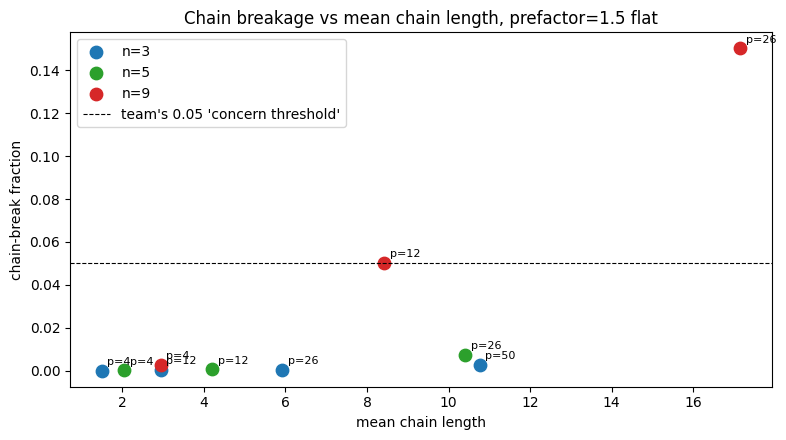

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {3:'#1f77b4', 5:'#2ca02c', 9:'#d62728'}
for n_val, sub in ran.groupby('n'):
    ax.scatter(sub['mean_chain'], sub['cbf'], s=80, label=f'n={n_val}', color=colors[n_val])
    for _, r in sub.iterrows():
        ax.annotate(f"p={int(r['p'])}", (r['mean_chain'], r['cbf']), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.axhline(0.05, color='k', ls='--', lw=0.8, label="team's 0.05 'concern threshold'")
ax.set_xlabel('mean chain length')
ax.set_ylabel('chain-break fraction')
ax.set_title('Chain breakage vs mean chain length, prefactor=1.5 flat')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
print(ran[['case', 'n', 'p', 'mean_chain', 'max_chain', 'cbf', 'SQA_valid', 'k_safety_violations', 'capacity_overruns']].to_string(index=False))

      case  n  p  mean_chain  max_chain    cbf  SQA_valid  k_safety_violations  capacity_overruns
 n-3_p-4_1  3  4        1.50        2.0 0.0000       True                  0.0                0.0
n-3_p-12_1  3 12        2.94        5.0 0.0003       True                  0.0                0.0
n-3_p-26_1  3 26        5.92       10.0 0.0004       True                  0.0                0.0
n-3_p-50_1  3 50       10.76       18.0 0.0026       True                  0.0                0.0
 n-5_p-4_1  5  4        2.05        3.0 0.0001       True                  0.0                0.0
n-5_p-12_1  5 12        4.20        6.0 0.0007       True                  0.0                0.0
n-5_p-26_1  5 26       10.41       19.0 0.0073       True                  0.0                0.0
 n-9_p-4_1  9  4        2.94        4.0 0.0026       True                  0.0                0.0
n-9_p-12_1  9 12        8.42       14.0 0.0503      False                  0.0                2.0
n-9_p-26_1  9 26    

**Read:** the tuning log in metadata says they lowered the prefactor to 1.5 because, across `n=3` cases, cbf stayed "50–500x below the 0.05 concern threshold." Their stop rule was *"if cbf rises notably on `n3_p50`, revert to 1.5/2.0"*. They monitored the wrong case.

- `n3_p50`: cbf = 0.0026 — still safe. The stop rule never fires.
- **`n9_p12`: cbf = 0.050** — exactly at the threshold, output is infeasible (2 capacity overruns).
- **`n9_p26`: cbf = 0.150** — 3x the threshold, 15 k-safety violations + 1 capacity overrun.

The "locked config" was validated on a problem class that turned out not to be representative.

## 7. Lambda calibration mixes two regimes within one sweep

In [10]:
ran['lambda_mode'] = ['exact' if v is not None and v <= 18 else 'heuristic' for v in ran['bqm_vars']]
ran['lambda_ratio'] = ran['lambda_1'] / ran['lambda_2']
print(ran[['case', 'bqm_vars', 'lambda_mode', 'lambda_1', 'lambda_2', 'lambda_ratio', 'gap_rel']].to_string(index=False))

      case  bqm_vars lambda_mode  lambda_1    lambda_2  lambda_ratio  gap_rel
 n-3_p-4_1      12.0       exact     394.5    0.100000        3945.0   0.0000
n-3_p-12_1      36.0   heuristic    2606.0  130.300000          20.0   0.8571
n-3_p-26_1      78.0   heuristic    3908.0   93.047619          42.0   1.8011
n-3_p-50_1     150.0   heuristic    9228.0  109.857143          84.0   0.6356
 n-5_p-4_1      20.0   heuristic    1462.0  243.666667           6.0   0.0709
n-5_p-12_1      60.0   heuristic    3476.0  289.666667          12.0   0.3143
n-5_p-26_1     130.0   heuristic    8034.0  309.000000          26.0   1.0851
 n-9_p-4_1      36.0   heuristic    2008.0 1004.000000           2.0   0.0091
n-9_p-12_1     108.0   heuristic    3982.0  497.750000           8.0   0.4022
n-9_p-26_1     234.0   heuristic   15194.0  949.625000          16.0   0.3260


`SQA_SF.calibrate_lambdas` switches modes at `n_vars <= 18`:

- **Exact path** (n_vars <= 18): grid-search vs `dimod.ExactSolver`. Used here only by `n-3_p-4` (12 vars) → ratio **3945**, `lambda_2 = 0.1`.
- **Heuristic path** (n_vars > 18): closed form `lambda_2 = h/max_C`, `lambda_1 = 2*max_C*lambda_2`. Used for every other case → ratios 2 – 84.

**The only case that matched ILP cost is the only case that used the exact path.** Every heuristic-lambda case produced a strictly inferior result. This is suggestive that the heuristic fallback is mis-calibrated, not that the QPU is failing — the BQM's ground state may not be the ILP optimum. Distinguishing these explanations requires (a) decoding the best raw sample back to the original objective and checking whether the BQM ground state IS the ILP optimum, or (b) running simulated S2 on the same BQM at full sweep budget and comparing. Neither is done in this file.

The `lambda_2 = 0.1` value is a separate flag: the exact grid sweeps `l2 in {0.1, 0.25, 0.5, ...}` and picks the *smallest* feasible pair. That makes the penalty parabola extremely shallow — fine when an exact solver verifies a feasible ground state exists, but a hazard on hardware where finite-temperature noise needs a stiffer penalty. The pattern is masked here because the only exact-mode case is also the smallest, but it's a footgun if `max_vars_for_exact` is ever raised.

## 8. Cost comparison: ILP vs SQA

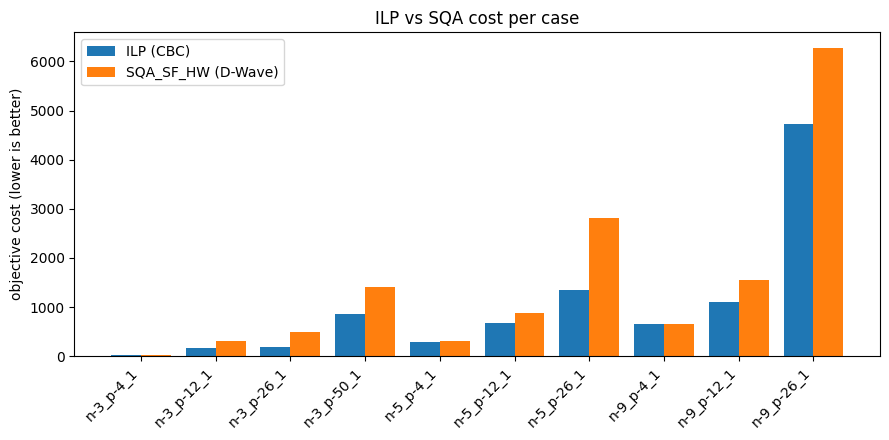

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(ran))
w = 0.4
ax.bar(x - w/2, ran['ILP_cost'], w, label='ILP (CBC)', color='#1f77b4')
ax.bar(x + w/2, ran['SQA_cost'], w, label='SQA_SF_HW (D-Wave)', color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(ran['case'], rotation=45, ha='right')
ax.set_ylabel('objective cost (lower is better)')
ax.set_title('ILP vs SQA cost per case')
ax.legend()
plt.tight_layout()
plt.show()

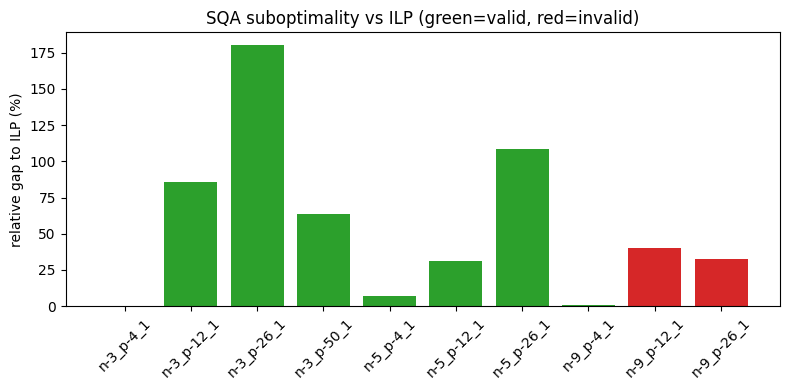

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ca02c' if v else '#d62728' for v in ran['SQA_valid']]
ax.bar(ran['case'], ran['gap_rel'] * 100, color=colors)
ax.set_ylabel('relative gap to ILP (%)')
ax.set_title('SQA suboptimality vs ILP (green=valid, red=invalid)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 9. Runtime: there is no comparison that favors the QPU

In [13]:
qpu_sum_s = ran['qpu_access_ms'].sum() / 1000.0
sqa_wall_s = ran['SQA_wall_ms'].sum() / 1000.0
ilp_wall_s = df['ILP_wall_ms'].sum() / 1000.0

print(f"ILP total wall time     : {ilp_wall_s:.2f} s  (every case solved to provable optimum)")
print(f"SQA pure QPU access     : {qpu_sum_s:.2f} s")
print(f"SQA wall (queue+net+QPU): {sqa_wall_s:.2f} s")
print()
print(f"Wall-clock end-to-end : ILP is ~{sqa_wall_s/ilp_wall_s:.0f}x faster than SQA.")
print(f"QPU-access only       : ILP is ~{qpu_sum_s/ilp_wall_s:.2f}x ...as fast... as SQA.")
print()
print(f"Of the SQA wall time, {(1 - qpu_sum_s/sqa_wall_s)*100:.1f}% is queue + network, not compute.")

ILP total wall time     : 1.16 s  (every case solved to provable optimum)
SQA pure QPU access     : 2.23 s
SQA wall (queue+net+QPU): 230.68 s

Wall-clock end-to-end : ILP is ~198x faster than SQA.
QPU-access only       : ILP is ~1.92x ...as fast... as SQA.

Of the SQA wall time, 99.0% is queue + network, not compute.


**Read:** at Tier-1 sizes (`n in {3,5,9}`, `p in {4,12,26,50}`) ILP-CBC solves every case to optimality in <250 ms each. The QPU's pure access time is roughly **2x slower** than ILP — and that's before queue/network, which is a further ~100x on top. There is no metric here under which the hardware path wins.

## 10. Bottom line

The file labels itself "final locked config" for a 36-case Tier-1 sweep. In practice it is:

1. A **12-case slice** (silent overwrite bug; 24 QPU submissions discarded).
2. With **2 embedding failures** (17%).
3. With **2 invalid outputs** (20% of the cases that did embed).
4. With **7/8 valid-but-suboptimal results** (median 36% above ILP, max 180%).
5. Where the only ILP-matching case is the only one whose lambdas were exactly calibrated, *and* the only one with `best_num_occurrences > 1`.
6. With actual `num_reads` != scheduled `num_reads` on at least three cases, undetected by the harness.
7. With chain-break behaviour above the team's own concern threshold on every `n=9` case that produced output.

This does not support any claim of quantum advantage, or even competitive performance, for the S2 formulation on `Advantage_system4` at Tier-1 sizes. It shows the pipeline runs end-to-end and that the BQM construction is feasible on small instances.

A defensible re-run would: (a) fix the dict-key collision so tightness is part of the case key; (b) record and surface the *actual* executed `num_reads`; (c) re-tune `chain_strength` against the `n=9` cases that drove the failures, not just `n=3`; (d) decouple "BQM ground state ≠ ILP optimum" from "QPU didn't find the BQM ground state" by sampling the same BQM with a high-budget classical solver before attributing the gaps to hardware.